In [1]:
# Install yfinance
!pip install yfinance

# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Select stock and time period
stock_symbol = 'AAPL'
data = yf.download(stock_symbol, start='2023-01-01', end='2026-01-01')

# Show first 5 rows
data.head()

/tmp/ipykernel_231/2022825546.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start='2023-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096016,128.833995,122.210219,128.223785,112117500
2023-01-04,124.365669,126.629372,123.105873,124.887303,89113600
2023-01-05,123.046799,125.753395,122.790908,125.123497,80962700
2023-01-06,127.574203,128.233627,122.918861,124.021187,87754700
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800


In [3]:
# Features: Open, High, Low, Volume
features = ['Open', 'High', 'Low', 'Volume']
X = data[features]

# Target: next day's Close
y = data['Close'].shift(-1)  # shift -1 moves next day's Close

# Drop last row with NaN target
X = X[:-1]
y = y[:-1]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (600, 4)
Test data shape: (151, 4)


In [4]:
# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr:.2f}")
print(f"Linear Regression R2 Score: {r2_lr:.2f}")

Linear Regression MSE: 12.06
Linear Regression R2 Score: 0.99


In [5]:
# Initialize and train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest R2 Score: {r2_rf:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest MSE: 130.02
Random Forest R2 Score: 0.84


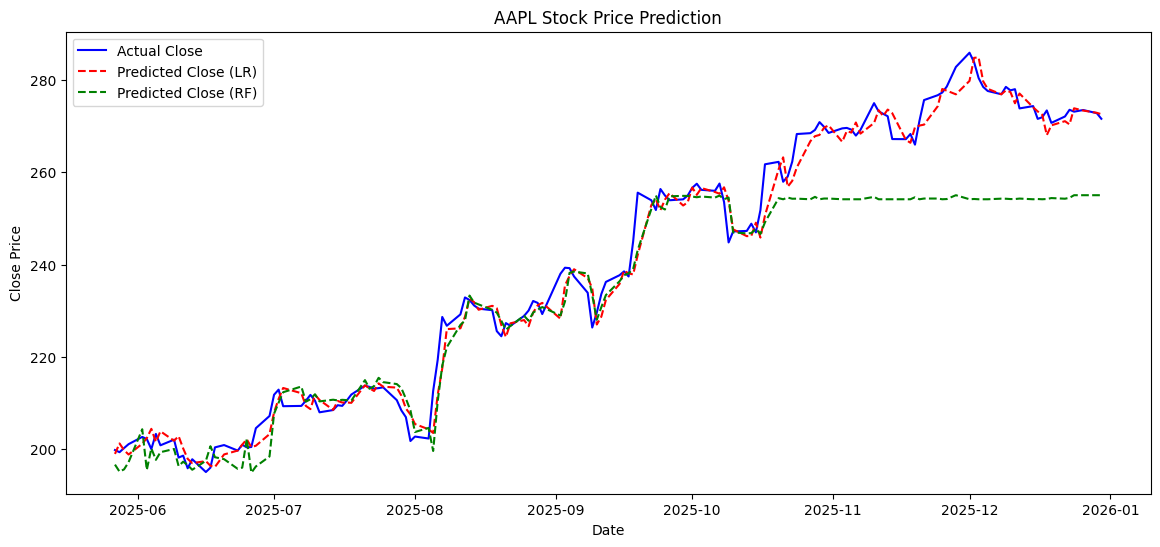

In [6]:
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, y_pred_lr, label='Predicted Close (LR)', color='red', linestyle='--')
plt.plot(y_test.index, y_pred_rf, label='Predicted Close (RF)', color='green', linestyle='--')
plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()